# Sistema de predicción de riesgo y costo esperado en seguros de auto

Este notebook contiene el flujo de trabajo completo para estimar los costos y beneficios de una compañía aseguradora enfocada al ramo del seguro de autos.

## 0. Importación de librerías necesarias

In [340]:
import matplotlib.pyplot as plt
import joblib
import json
import sys

import seaborn as sns
import plotly.express as px

import scipy.stats as stats
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, Lasso
from sklearn.metrics import f1_score, accuracy_score, mean_absolute_error, mean_squared_error, r2_score ,precision_score, recall_score, ConfusionMatrixDisplay, average_precision_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.compose import ColumnTransformer
from sklearn.utils.class_weight import compute_sample_weight

from ipywidgets import interact, Dropdown, IntSlider, Checkbox, fixed

RANDOM_STATE = 42
BASE_DIR = Path.cwd().parent
DATA_PATH = BASE_DIR / "data" / "seguro_auto_actuarial.csv"
MODELS_DIR = BASE_DIR / "models"
OUTPUTS_DIR = BASE_DIR / "outputs"
UTILS_DIR = BASE_DIR / "utils"
ASSETS_DIR = BASE_DIR / "assets" / "imagenes_ejemplo_vehiculos"

for carpeta in [MODELS_DIR, OUTPUTS_DIR, UTILS_DIR, ASSETS_DIR]:
    carpeta.mkdir(parents = True, exist_ok = True)
print("Raíz del proyecto:", BASE_DIR)



Raíz del proyecto: c:\Users\PC\OneDrive\Documentos\GitHub\proyecto_seguro_actuarial


In [341]:
## Se crea una funcion para podre pasarla a utils

# nbins es el número de intervalos que va a hacer en el continuo de los valores numericos

def histograma_plotly(data, variable_num, variable_cat, nbins = 40, por_cateogria = True):
    # Generamos el histograma con el marginal tipo box, pues esto hace posible ver los outliers mediante el método de IQR
    
    # Si queremos diferenciarlos por cateogrías
    if por_cateogria:
        fig = px.histogram(
            data,           
            x=variable_num, 
            color=variable_cat, # Diferenciar los datos por color mediante su categoría
            marginal="box",     # Agrega boxplot, o diagrama de caja y bigotes para ver el IQR  y por ende los outliers         
            barmode="overlay",  # Hace que se hagan menos opacos los histogrammas para verlos mejor         
            nbins= nbins,                     
            title=f"Distribución de {variable_num.replace('_', ' ').title()} por {variable_cat.replace('_', ' ').title()}",
            template="plotly_white",      # Un fondo blanco limpio y estético
            color_discrete_sequence=px.colors.qualitative.Safe # Paleta de colores moderna
        )

    # O bien, ver la distribución de la muestra para cada categoría numerica
    else: 
         fig = px.histogram(
            data, 
            x=variable_num, 
         
            marginal="box",               
            barmode="overlay",            
            nbins= nbins,                     
            title=f"Distribución de {variable_num.replace('_', ' ').title()}",
            template="plotly_white",      # Un fondo blanco limpio y estético
            color_discrete_sequence=px.colors.qualitative.Safe # Paleta de colores moderna       
        )
         
    fig.update_xaxes(title_text = variable_num.replace('_', ' ').title())
    fig.update_yaxes(title_text = 'Recuento')

    fig.update_layout(
    legend_title_text = variable_cat.replace('_', ' ').title(), 
    height=1000,
    title_font_size=18,
    hovermode="x unified"  # Agrupa el tooltip para ver todas las categorías juntas al pasar el mouse
    )

    return fig
    
def Balance_de_Clases(data, categoria):
    Conteo = data[categoria].value_counts().reset_index()
    Conteo.columns = ['Categoría', 'Cantidad']
    Conteo['Proporcion'] = Conteo['Cantidad']/Conteo['Cantidad'].sum().round(4)

    fig = px.bar(
        Conteo, 
        x = 'Categoría',
        y = 'Cantidad',
        text = Conteo['Proporcion'],
        title=f"Análisis de Balance de Clases de: {categoria.replace('_', ' ').title()}",
        template="plotly_white",
        color='Categoría',
        color_discrete_sequence=px.colors.qualitative.Pastel
    )

    fig.update_traces(textposition='outside') # Coloca el texto del % fuera de la barra
    fig.update_layout(
        yaxis_title="Número de Registros",
        xaxis_title=categoria.replace('_', ' ').title()
    )

    return fig

In [342]:
def Outlier_descriptive(data, columna, describe = False):

    n = data[columna].count()

    p995 = data[columna].quantile(0.995)
    p999 = data[columna].quantile(0.999)

    r = data[columna].std()
    mean =  data[columna].mean()

    desvest_3 = mean + 3*r

    q3 = data[columna].quantile(0.75) 
    q1 = data[columna].quantile(0.25)
    iqr =  q3 - q1
    
    uper_fence = q3 + (1.5 *iqr)
    lower_fence = q1 - (1.5 *iqr)
    ## Si gamma distribuida
    alpha = (mean / r)** 2
    beta = (r **2)/ mean


    # Calcular la probabilidad acumulada de la cola derecha
    prob_extremo = 1 - stats.gamma.cdf(desvest_3, a=alpha, scale=beta)

    if describe:
      print(f"Probabilidad exacta de un evento > 3 sigma si es gamma: {prob_extremo:.5f}, \n",
            'Si son', n, 'observaciones, podriamos esperar hasta', prob_extremo*n, 'observaciones en la cola\n')


      print(
      'Numero de observaciones despues del percentil 99.5 : ', data[data[columna] > p995][columna].count(),
      'Numero de observaciones despues del percentil 99.9 : ', data[data[columna] > p999][columna].count(),
      '\nNumero de observaciones despues de media mas 3 desv. est. : ', data[data[columna] > desvest_3 ][columna].count(),
      '\nNumero de observaciones despues del 150% del IQR (Tukey): ', data[data[columna] > uper_fence][columna].count()
      )
    return {'Percentil 99.5': p995,
            'Percentil 99.9': p999,
            'Media +3 desv. est.': desvest_3,
            'Upperfence':uper_fence,
            'LowerFence':lower_fence


            }

## 1. Carga de la base de datos

In [343]:
df = pd.read_csv(DATA_PATH)
df = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)
df.head()

,poliza_id,edad_conductor,sexo,estado_civil,nivel_estudios,ocupacion,zona_residencia,region,antiguedad_cliente_anios,ingreso_mensual_mxn,...,canal_venta,tiene_gps,asistencia_vial,mantenimiento_al_dia,dias_hasta_renovacion,puntaje_riesgo_zona,numero_siniestros_12m,costo_esperado_anual_mxn,riesgo_alto,clase_costo
0,POL-00001,46,Femenino,Soltero,Posgrado,Independiente,Urbana,Sur,9.4,7038.0,...,Agente,Si,Si,Si,170,74.7,0,3321,0,Bajo
1,POL-00002,38,Masculino,Casado,Licenciatura,Estudiante,Suburbana,Centro,0.9,19655.0,...,Agente,No,No,Si,100,57.4,0,7196,0,Medio
2,POL-00003,48,Masculino,Divorciado,Licenciatura,Empleado,Urbana,Centro,0.1,16140.0,...,Agente,No,No,Si,69,71.3,0,2046,0,Bajo
3,POL-00004,60,Femenino,Divorciado,Licenciatura,Empleado,Urbana,Sur,0.1,14954.0,...,Online,Si,No,No,173,83.4,0,1379,0,Bajo
4,POL-00005,37,Femenino,Soltero,Preparatoria,Empleado,Urbana,Centro,3.9,27192.0,...,Agente,Si,Si,No,188,73.6,1,11787,1,Alto


Marcaremos póliza id como index de la base de datos, así evitamos usarla como predictor accidentalmente.

In [344]:
df = df.set_index("poliza_id")
df.index = df.index.str.replace('POL-', '').astype(int)
df.head()

,edad_conductor,sexo,estado_civil,nivel_estudios,ocupacion,zona_residencia,region,antiguedad_cliente_anios,ingreso_mensual_mxn,score_crediticio,...,canal_venta,tiene_gps,asistencia_vial,mantenimiento_al_dia,dias_hasta_renovacion,puntaje_riesgo_zona,numero_siniestros_12m,costo_esperado_anual_mxn,riesgo_alto,clase_costo
poliza_id,,,,,,,,,,,,,,,,,,,,,
1,46,Femenino,Soltero,Posgrado,Independiente,Urbana,Sur,9.4,7038.0,613.0,...,Agente,Si,Si,Si,170,74.7,0,3321,0,Bajo
2,38,Masculino,Casado,Licenciatura,Estudiante,Suburbana,Centro,0.9,19655.0,565.0,...,Agente,No,No,Si,100,57.4,0,7196,0,Medio
3,48,Masculino,Divorciado,Licenciatura,Empleado,Urbana,Centro,0.1,16140.0,641.0,...,Agente,No,No,Si,69,71.3,0,2046,0,Bajo
4,60,Femenino,Divorciado,Licenciatura,Empleado,Urbana,Sur,0.1,14954.0,570.0,...,Online,Si,No,No,173,83.4,0,1379,0,Bajo
5,37,Femenino,Soltero,Preparatoria,Empleado,Urbana,Centro,3.9,27192.0,586.0,...,Agente,Si,Si,No,188,73.6,1,11787,1,Alto


In [345]:
# Interacción, transformación y discretización de variables
df_muestreo = df.copy()
df_muestreo['km_totales'] = df_muestreo['km_anuales'] * df_muestreo['edad_vehiculo_anios']
df_muestreo['log_km_totales'] = np.log1p(df_muestreo['km_totales'])
df_muestreo['log_ingreso_mensual_mxn'] = np.log1p(df_muestreo['ingreso_mensual_mxn'])
df_muestreo['log_suma_asegurada'] = np.log1p(df_muestreo['suma_asegurada_mxn'])

df_muestreo['siniestros_en_12m'] = np.where(df_muestreo['numero_siniestros_12m'] > 0, 'Si', 'No')
df_muestreo['prima_mayor_a_mediana'] = np.where(df_muestreo['prima_mensual_mxn'] > df_muestreo['prima_mensual_mxn'].median(), 'Si', 'No')

df_muestreo['grupo_edad_conductor'] = pd.cut(
            df_muestreo['edad_conductor'],
            bins=[17, 25, 35, 50, 65, np.inf],
            labels=['18-25', '26-35', '36-50', '51-65', '66+'],
            include_lowest=True
        ).astype(str)

## Selección de Variables Numericas y Categorícas

In [346]:
tipos = {}

for i in df_muestreo.dtypes.unique():
    tipos_key = str(i)
    columnas = df_muestreo.select_dtypes(include = [i]).columns.tolist()
    tipos[tipos_key] = columnas

numerico = []

categorica = []

for j in tipos.keys():
   for i in tipos[j]:
      if(len(df_muestreo[i].value_counts().index.to_list()) < 10):  ## cuantos valores unicos tiene
         categorica.append(i)

      else:
         numerico.append(i)


categorica.remove('historial_siniestros_3_anios')
categorica.remove('numero_siniestros_12m')

numerico.append('historial_siniestros_3_anios')
numerico.append('numero_siniestros_12m')



## 2. Análisis de datos

Objetivo: Mostrar dimensiones, tipos de variables, valores faltantes, distribuciones, correlaciones y balance de clases.

### 2.1 Mostrar dimensiones

In [347]:
print("Dimensiones de la base de datos", df.shape)

Dimensiones de la base de datos (1500, 30)


### 2.2 Tipos de variables y valores faltantes

Comenzamos mostrando una tabla con la información solicitada

In [348]:
analisis = pd.DataFrame({
    "Tipo de dato": df.dtypes,
    "Valores faltantes": df.isnull().sum(),
    "Porcentaje": 100 * df.isnull().sum() / len(df),
    "Valores unicos": df.nunique()
}).sort_values(["Porcentaje"], ascending = False)
analisis

,Tipo de dato,Valores faltantes,Porcentaje,Valores unicos
ingreso_mensual_mxn,float64,106,7.066667,1358
score_crediticio,float64,85,5.666667,332
ocupacion,str,81,5.400000,6
puntaje_riesgo_zona,float64,53,3.533333,486
mantenimiento_al_dia,str,46,3.066667,2
segmento_marca,str,44,2.933333,3
zona_residencia,str,0,0.000000,3
nivel_estudios,str,0,0.000000,4
antiguedad_cliente_anios,float64,0,0.000000,166
region,str,0,0.000000,5


,Tipo de dato,Valores faltantes,Porcentaje,Valores unicos
ingreso_mensual_mxn,float64,106,7.066667,1358
score_crediticio,float64,85,5.666667,332
ocupacion,str,81,5.400000,6
puntaje_riesgo_zona,float64,53,3.533333,486
mantenimiento_al_dia,str,46,3.066667,2
segmento_marca,str,44,2.933333,3


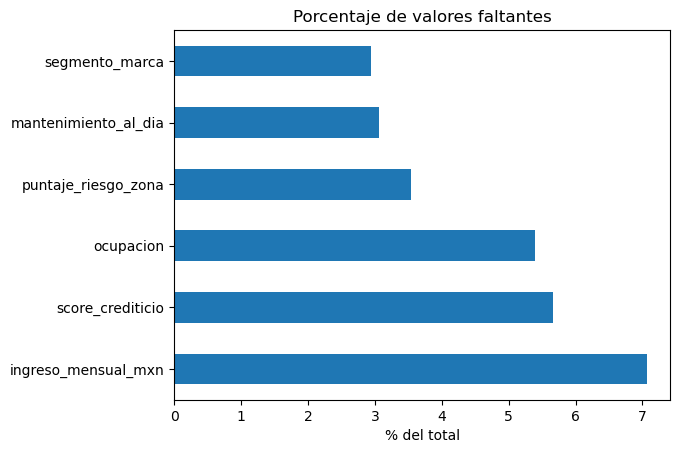

In [349]:
variables_con_faltante = analisis.loc[analisis["Valores faltantes"] > 0]
display(variables_con_faltante)

variables_con_faltante["Porcentaje"].plot(kind = "barh")
plt.title("Porcentaje de valores faltantes")
plt.xlabel("% del total")
plt.show()

Podemos observar que el porcentaje de valores faltantes es muy bajo.

### 2.3 Balance de clases

Basándonos en lo que se solicitará más adelante, revisaremos únicamente el balance de la clase riesgo alto.

In [350]:
interact(
    Balance_de_Clases, 
    data = fixed(df_muestreo),
    categoria=Dropdown(options= categorica, value='riesgo_alto', description='Variable:')
)

interactive(children=(Dropdown(description='Variable:', index=1, options=('deducible_pct', 'riesgo_alto', 'sex…

<function __main__.Balance_de_Clases(data, categoria)>

Como análisis preeliminar podemos observar que los riesgos altos representan apenas un ~15% de la cartera, algo que tendremos que considerar al implementar nuestros modelos predictivos, pues decir siempre "no" dará un accuracy muy alto y habrá que usar otras evaluaciones.

### 2.4 Correlaciones

In [351]:
columnas_numericas = df.select_dtypes(include=['float64', 'int64']).columns
columnas_numericas = columnas_numericas.drop(["riesgo_alto"])
correlaciones = df[columnas_numericas].corr()

<Axes: >

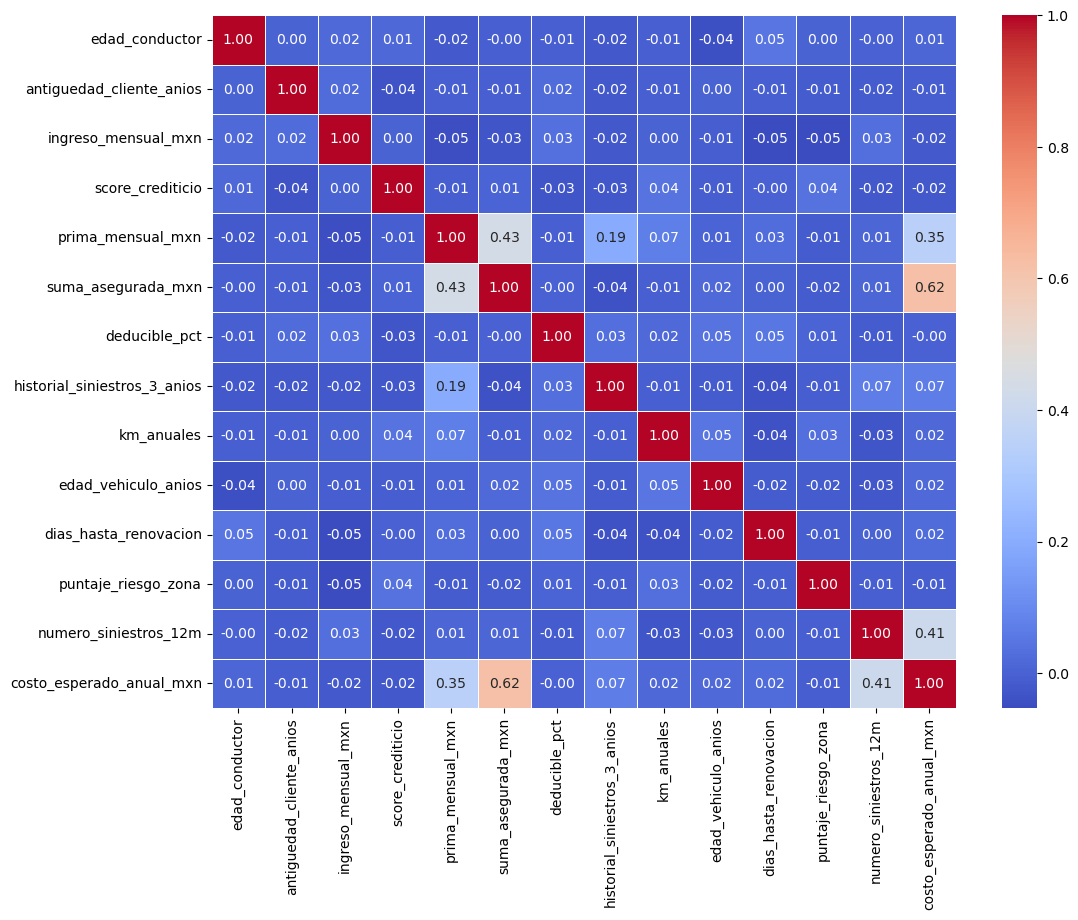

In [352]:

plt.figure(figsize = (12,9))
sns.heatmap(
    correlaciones,
    annot = True,
    cmap="coolwarm",  
    fmt=".2f",  
    vmax=1,  
    linewidths=0.5
    )

### 2.5 Distribuciones

Nuevamente, al ser demasiadas, sólo se presentará la distribución de las variables que consideramos más importantes

In [353]:
interact(
    histograma_plotly,
    data = fixed(df_muestreo),
    variable_num = Dropdown(options = numerico,value = 'costo_esperado_anual_mxn', description = 'Numérica'),
    variable_cat = Dropdown(options = categorica, value = 'zona_residencia', description = 'Categoría:'),
    nbins = IntSlider(min = 10, max = 250, step = 1, value = 40, description = 'Intervalos: '),
    por_cateogria = Checkbox(description = 'Categorias', value = True)
)

interactive(children=(Dropdown(description='Numérica', index=2, options=('edad_conductor', 'dias_hasta_renovac…

<function __main__.histograma_plotly(data, variable_num, variable_cat, nbins=40, por_cateogria=True)>

Algo interesante a destacar aquí es que un gran porcentaje los clientes pagan la prima mínima, lo que aumenta la importancia de controlar los riesgos adecuadamente, pues el 15% de "riesgo alto" que identificamos anteriormente no se corresponde con el pago de primas.

## 3. Preprocesamiento

### 3.1 División de datos

Optamos por dividir los datos antes de normalizar, imputar o escalar. El objetivo es evitar en lo posible el data leaking. Estratificamos por riesgos para mantener estable la proporción de positivos, mejorando el entrenamiento. En vez de partir los datos en varios sets optamos por simplemente guardar el id de los datos que estarían  en los distintos sets.

Cuando terminamos el proyecto notamos que daba resultados excepcionalmente buenos, esto era debido al data leakage que se daba por probar estrategias (para elegir los mejores parámetros) con el mismo set que después se testeaban. Corregimos implementando tres conjuntos:

- Test para entrenamiento
- Validación para comparación de modelos y selección de parámetros
- Test para análisis final

In [354]:

## Eliminación de Outliers(Explicada Más abajo)


df['log_suma_asegurada'] = np.log1p(df_muestreo['suma_asegurada_mxn'])
df['log_costo'] = np.log(df['costo_esperado_anual_mxn'])
df['ratio_costo_prima'] = df['costo_esperado_anual_mxn']/df['prima_mensual_mxn']


df = df[
    (df['log_costo'] < Outlier_descriptive(data = df, columna='log_costo')['Percentil 99.5']) 
    
    &(df['log_suma_asegurada'] < Outlier_descriptive(data = df, columna='log_suma_asegurada')['Percentil 99.5'])

    &(df['ratio_costo_prima'] < Outlier_descriptive(data = df, columna='ratio_costo_prima')['Percentil 99.5'])
    ]

df.drop(['ratio_costo_prima', 'log_suma_asegurada', 'log_costo'], axis = 1)

df.count()

edad_conductor                  1480
sexo                            1480
estado_civil                    1480
nivel_estudios                  1480
ocupacion                       1402
zona_residencia                 1480
region                          1480
antiguedad_cliente_anios        1480
ingreso_mensual_mxn             1374
score_crediticio                1395
prima_mensual_mxn               1480
suma_asegurada_mxn              1480
deducible_pct                   1480
historial_siniestros_3_anios    1480
km_anuales                      1480
edad_vehiculo_anios             1480
tipo_vehiculo                   1480
uso_vehiculo                    1480
segmento_marca                  1436
metodo_pago                     1480
canal_venta                     1480
tiene_gps                       1480
asistencia_vial                 1480
mantenimiento_al_dia            1434
dias_hasta_renovacion           1480
puntaje_riesgo_zona             1427
numero_siniestros_12m           1480
c

In [355]:
interact(
    histograma_plotly,
    data = fixed(df),
    variable_num = Dropdown(options = numerico,value = 'costo_esperado_anual_mxn', description = 'Numérica'),
    variable_cat = Dropdown(options = categorica, value = 'zona_residencia', description = 'Categoría:'),
    nbins = IntSlider(min = 10, max = 250, step = 1, value = 40, description = 'Intervalos: '),
    por_cateogria = Checkbox(description = 'Categorias', value = True)
)

interactive(children=(Dropdown(description='Numérica', index=2, options=('edad_conductor', 'dias_hasta_renovac…

<function __main__.histograma_plotly(data, variable_num, variable_cat, nbins=40, por_cateogria=True)>

In [356]:
id_train_val, id_test = train_test_split(
    df.index,
    test_size = 0.20,
    random_state = RANDOM_STATE,
    stratify = df["riesgo_alto"]
)

id_train, id_val = train_test_split(
    id_train_val,
    test_size = 0.25,
    random_state = RANDOM_STATE,
    stratify = df.loc[id_train_val, "riesgo_alto"]
)

print("Elementos train:",len(id_train))
print("Elementos val:",len(id_val))
print("Elementos test:",len(id_test))

Elementos train: 888
Elementos val: 296
Elementos test: 296


### 3.2 Detección de outliers

In [357]:
outliers = []

for col in columnas_numericas:
    

    ## Tukey (IQR)
    lim_inf = Outlier_descriptive(df, col)['LowerFence']
    lim_sup = Outlier_descriptive(df, col)['Upperfence']

    ## 3 veces desv_est (solo derecha)
    sd3 = Outlier_descriptive(df,col)['Media +3 desv. est.']



    df_outliers1 = df[(df[col] < lim_inf) | (df[col] > lim_sup)]

    df_outliers2 = df[ ( df[col] > sd3 )]

    porcentaje1 = 100 * len(df_outliers1) / len(df)
    porcentaje2 = 100 * len(df_outliers2) / len(df)
    
    outliers.append({
        "Columna": col,
        "Cantidad de outliers(Tukey)": len(df_outliers1),
        "Porcentaje(Tukey)": round(porcentaje1, 2),
        "Cantidad de outliers(Media + 3 desv. est)": len(df_outliers2),
        "Porcentaje(Media + 3 desv. est)": round(porcentaje2, 2)
    })

df_outliers = pd.DataFrame(outliers)

df_outliers_ordenado = df_outliers.sort_values(by="Porcentaje(Tukey)", ascending=True)
df_outliers_ordenado

,Columna,Cantidad de outliers(Tukey),Porcentaje(Tukey),Cantidad de outliers(Media + 3 desv. est),Porcentaje(Media + 3 desv. est)
6,deducible_pct,0,0.00,0,0.00
10,dias_hasta_renovacion,0,0.00,0,0.00
11,puntaje_riesgo_zona,1,0.07,0,0.00
0,edad_conductor,3,0.20,0,0.00
8,km_anuales,5,0.34,2,0.14
3,score_crediticio,12,0.81,0,0.00
7,historial_siniestros_3_anios,14,0.95,14,0.95
9,edad_vehiculo_anios,34,2.30,17,1.15
2,ingreso_mensual_mxn,63,4.26,13,0.88
1,antiguedad_cliente_anios,66,4.46,32,2.16


Los outliers no se eliminarán. En seguros, estas observaciones extremas son plausibles y ayudan a estimar gastos máximos en accidentes de alta severidad. La estrategia será conservar y aplicar las transformaciones necesarias.

### 3.3 Uso de MinMaxScaler

En esta sección, se reescalarán dos variables únicamente como demostración y para cumplir con el requisito. Los modelos usarán un pipeline como se especifica.

MinMaxScaler es particularmente útil cuando las variables están contenidas en un intervalo definidio y, preferentemente, tienen pocos o ningún outilier, ya que es sensible a los mismos, sin embargo, según la documentación de Scikit learn, reduce un poco su efecto por reducir la escala a un rango determinado. Por ello elegimos variables con pocos outliers.

Una de las ventajas más interesantes de MinMax es que puede usarse con presencia de valores nulos, donde solo se ignorarn en la fase del escalamiento y se mantienen como faltantes en el resultado final.

In [358]:
variables_minmax = ["km_anuales", "edad_conductor"]
prueba_minmax = df[variables_minmax].copy()
minmax_scaler = MinMaxScaler()

temp = [f"{col}_minmax" for col in variables_minmax]
prueba_minmax[temp] = minmax_scaler.fit_transform(prueba_minmax[variables_minmax])
prueba_minmax.describe()

,km_anuales,edad_conductor,km_anuales_minmax,edad_conductor_minmax
count,1480.000000,1480.000000,1480.000000,1480.000000
mean,15599.552027,40.714189,0.348068,0.398495
std,5541.200873,12.429221,0.147235,0.218057
min,2500.000000,18.000000,0.000000,0.000000
25%,11859.750000,32.000000,0.248698,0.245614
50%,15604.500000,41.000000,0.348200,0.403509
75%,19318.750000,49.000000,0.446891,0.543860
max,40135.000000,75.000000,1.000000,1.000000


### 3.4 Imputación de valores numéricos

Nuevamente, será sólo demostrativo. Se seleccionó la opción de la mediana por ser financieramente robusta (soporta mejor asimetrías, comunes en este tipo de datos).

In [359]:
imputer_knn = KNNImputer(n_neighbors = 3, weights = "uniform")

prueba_imputer = df.copy()
print("Columnas con valores null antes del imputer numérico")
columnas_imputer = df[columnas_numericas].columns[df[columnas_numericas].isnull().any()]
display(prueba_imputer[prueba_imputer.columns[prueba_imputer.isnull().any()]].head())

if len(columnas_imputer) > 0:
    prueba_imputer[columnas_imputer] = imputer_knn.fit_transform(prueba_imputer[columnas_imputer])

print("Columnas con valores null después del imputer numérico")
display(prueba_imputer[prueba_imputer.columns[prueba_imputer.isnull().any()]].head())


Columnas con valores null antes del imputer numérico


,ocupacion,ingreso_mensual_mxn,score_crediticio,segmento_marca,mantenimiento_al_dia,puntaje_riesgo_zona
poliza_id,,,,,,
1,Independiente,7038.0,613.0,Economico,Si,74.7
2,Estudiante,19655.0,565.0,Medio,Si,57.4
3,Empleado,16140.0,641.0,Economico,Si,71.3
4,Empleado,14954.0,570.0,Economico,No,83.4
5,Empleado,27192.0,586.0,Economico,No,73.6


Columnas con valores null después del imputer numérico


,ocupacion,segmento_marca,mantenimiento_al_dia
poliza_id,,,
1,Independiente,Economico,Si
2,Estudiante,Medio,Si
3,Empleado,Economico,Si
4,Empleado,Economico,No
5,Empleado,Economico,No


### 3.5 Creación de preprocessing.py

Añadimos la creación del archivo de preprocesamiento solicitado. Se usará para:

- Generar al menos una variable nueva mediante interacción o transformación
- Discretizar una variable numérica

In [360]:
preprocessing_code = r'''
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin


class ActuarialFeatureEngineer(BaseEstimator, TransformerMixin):

    def fit(self, X, y = None):
        # Esta parte se entrena únicamente con lo recibido en fit para evitar data leakage
        prima = pd.to_numeric(X["prima_mensual_mxn"], errors="coerce")
        self.prima_mediana_ = prima.median()
        return self

    def transform(self, X):
        X = X.copy()

        ingreso = pd.to_numeric(X["ingreso_mensual_mxn"], errors='coerce').clip(lower=0)
        suma = pd.to_numeric(X["suma_asegurada_mxn"], errors='coerce').clip(lower=0)
        edad = pd.to_numeric(X["edad_conductor"], errors='coerce')
        edad_carro = pd.to_numeric(X['edad_vehiculo_anios'], errors='coerce')
        km_anuales = pd.to_numeric(X['km_anuales'], errors='coerce')
        prima = pd.to_numeric(X["prima_mensual_mxn"], errors = 'coerce')
        siniestros_12m = pd.to_numeric(X["numero_siniestros_12m"], errors = 'coerce')

        X["log_ingreso_mensual"] = np.log1p(ingreso)
        X["log_suma_asegurada"] = np.log1p(suma)

        X['km_totales'] = edad_carro * km_anuales
        X['log_km_totales'] = np.log1p(X["km_totales"])

        X['siniestros_en_12m'] = np.where(siniestros_12m > 0, "Si", "No")
        X['prima_mayor_a_mediana'] = np.where(prima > self.prima_mediana_, "Si", "No")
        
        X['grupo_edad_conductor'] = pd.cut(
            edad,
            bins=[17, 25, 35, 50, 65, np.inf],
            labels=['18-25', '26-35', '36-50', '51-65', '66+'],
            include_lowest=True
        ).astype(object)


        return X
'''

(UTILS_DIR / 'preprocessing.py').write_text(preprocessing_code, encoding='utf-8')

if str(BASE_DIR) not in sys.path:
    sys.path.insert(0, str(BASE_DIR))

from utils.preprocessing import ActuarialFeatureEngineer
print('Creado:', UTILS_DIR / 'preprocessing.py')

Creado: c:\Users\PC\OneDrive\Documentos\GitHub\proyecto_seguro_actuarial\utils\preprocessing.py


### 3.6 Separación de variables numéricas, nominales y ordinales.

La separación se hizo siguiendo la tabla proporcionada.

In [361]:
OBJETIVOS = ["costo_esperado_anual_mxn", "riesgo_alto"]

NUMERICAS = columnas_numericas.drop(["costo_esperado_anual_mxn"]).tolist()

NUMERICAS_MODIFICADAS = ["log_ingreso_mensual", "log_suma_asegurada",
                         'km_totales', 'log_km_totales']

ORDINALES = ["nivel_estudios","segmento_marca"]

BINARIAS = ['tiene_gps', 'asistencia_vial', 'mantenimiento_al_dia'] # Riesgo alto está señalada también. Se omite pues será nuestra variable objetivo


var_nominal = []
for cols in df:
    if cols not in ORDINALES and cols not in NUMERICAS and cols not in BINARIAS and cols not in OBJETIVOS and cols != "clase_costo" :
        var_nominal.append(cols)


ORDEN_ESTUDIOS = ["Secundaria", "Preparatoria", "Licenciatura", "Posgrado"]
ORDEN_MARCA = ["Economico", "Medio", "Premium"]


NOMINALES = var_nominal



NOMINAL_MODIFICADA = ["grupo_edad_conductor"]

BINARIA_MODIFICADA = ['siniestros_en_12m', 'prima_mayor_a_mediana']

FEATURES = NUMERICAS + NOMINALES + BINARIAS + ORDINALES

def configurar(excluir_adicional=()):
    excluir = set(OBJETIVOS) | set(excluir_adicional)
    columnas_input = [c for c in FEATURES if c not in excluir]

    numericas_cols = [c for c in NUMERICAS if c in columnas_input and c not in {"ingreso_mensual_mxn", "suma_asegurada_mxn"}] + NUMERICAS_MODIFICADAS

    nominal_cols = [c for c in NOMINALES if c in columnas_input] + NOMINAL_MODIFICADA

    ordinal_cols = [c for c in ORDINALES if c in columnas_input]

    binarias_cols = [c for c in BINARIAS if c in columnas_input] + BINARIA_MODIFICADA

    return{
        "columnas_input": columnas_input,
        "numericas_cols": numericas_cols,
        "nominal_cols": nominal_cols,
        "ordinal_cols": ordinal_cols,
        "binarias_cols": binarias_cols
    }

Como siguen un proceso similar, omitiremos el manejo de datos categóricos e iremos directamente a la implementación de pipelines.

### 3.7 Codificación con Pipeline y ColumnTransformer

El objetivo es construir un Pipeline que reciba datos crudos y aplique:

- imputación numérica por mediana.
- Cualquier otro tipo de imputación por moda.
- StandardScaler para modelos sensibles a escala.
- One-Hot Encoding nominal con tolerancia a categorías nuevas.
- Ordinal Encoding justificado.
- codificación de binarias.

In [362]:
def crea_OHEncoder():
    return OneHotEncoder(handle_unknown = "ignore", sparse_output = False)

def crea_preprocesador(escalar_numericas = True, excluir_adicionales=()):
    conf = configurar(excluir_adicionales)

    paso_numericos = [("imputer", KNNImputer(n_neighbors = 3, weights = "uniform"))]
    if escalar_numericas:
        paso_numericos.append(("scaler", StandardScaler()))
    numerico_pipeline = Pipeline(paso_numericos)

    nominal_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy = "most_frequent")),
        ("onehot", crea_OHEncoder())
    ])

    categorias_ordinales = []
    for col in conf["ordinal_cols"]:
        if col == "nivel_estudios":
            categorias_ordinales.append(ORDEN_ESTUDIOS)
        elif col == "segmento_marca":
            categorias_ordinales.append(ORDEN_MARCA)

        else:
            raise ValueError("Esta columna no está definida")
        
    ordinal_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy = "most_frequent")),
        ("ordinal", OrdinalEncoder(
            categories = categorias_ordinales, 
        ))
    ])
    
    categorias_binarias = [["No", "Si"] for _ in conf["binarias_cols"]]
    binario_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy = "most_frequent")),
        ("binary", OrdinalEncoder(
            categories = categorias_binarias
        ))
    ])

    preprocesador = ColumnTransformer([
        ("numerico", numerico_pipeline, conf["numericas_cols"]),
        ("nominal", nominal_pipeline, conf["nominal_cols"]),
        ("ordinal", ordinal_pipeline, conf["ordinal_cols"]),
        ("binario", binario_pipeline, conf["binarias_cols"])
    ], remainder = "drop", verbose_feature_names_out = True)

    return preprocesador



def crear_pipeline(modelo, escalar_numericas = True, excluir_adicionales=()):
    return Pipeline([
        ("feature_engineering", ActuarialFeatureEngineer()),
        ("preprocesado", crea_preprocesador(escalar_numericas, excluir_adicionales)),
        ("model", modelo)
    ])

def nombres_features(pipeline):
    return pipeline.named_steps["preprocesado"].get_feature_names_out()

## 4. Entrenamiento

Al haber tantas pruebas y modelos, hay demasiadas métricas para analizar, por lo que decidimos crear funciones evaluadoras.

In [363]:
def metricas_regresion(y_real, y_pred):
    return{
        "MAE": mean_absolute_error(y_real, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_real, y_pred)),
        "R2": r2_score(y_real, y_pred)
    }
def metricas_clasificacion(y_real, probas, umbral = 0.50):
    pred = (np.asarray(probas) >= umbral)
    tn, fp, fn, tp = confusion_matrix(y_real, pred, labels=[0,1]).ravel()
    return{
        "accuracy": accuracy_score(y_real, pred),
        "precision": precision_score(y_real, pred, zero_division = 0),
        "recall": recall_score(y_real, pred, zero_division = 0),
        "F1": f1_score(y_real, pred, zero_division = 0),
        "ROC_AUC": roc_auc_score(y_real, probas),
        "PR_AUC": average_precision_score(y_real, probas),
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp)
    }
def extraer_proba(pipeline, X):
    probas = pipeline.predict_proba(X)
    clases = list(pipeline.named_steps["model"].classes_)
    return probas[:, clases.index(1)]

def ajustar_pipeline(pipe, X, y, ponderar = False):
    temp = {}
    if ponderar:
        temp["model__sample_weight"] = compute_sample_weight(class_weight = "balanced", y=y)
    pipe.fit(X,y, **temp)
    return pipe

Creamos los sets de entrenamiento

In [364]:
config = configurar()
X_train = df.loc[id_train, config["columnas_input"]]
X_val = df.loc[id_val, config["columnas_input"]]
X_test = df.loc[id_test, config["columnas_input"]]
X_train_val = df.loc[id_train_val, config["columnas_input"]]

y_reg_train = df.loc[id_train, "costo_esperado_anual_mxn"]
y_reg_val = df.loc[id_val, "costo_esperado_anual_mxn"]
y_reg_test = df.loc[id_test, "costo_esperado_anual_mxn"]
y_reg_train_val = df.loc[id_train, "costo_esperado_anual_mxn"]

y_clas_train = df.loc[id_train, "riesgo_alto"]
y_clas_val = df.loc[id_val, "riesgo_alto"]
y_clas_test = df.loc[id_test, "riesgo_alto"]
y_clas_train_val = df.loc[id_train_val, "riesgo_alto"]

### 4.1 Entrenamiento de modelos de regresión

In [365]:
modelos_regresion = {
    "Dummy mediana": DummyRegressor(strategy = "median"), # Añadimos un modelo dummy para comprobar la mejora de los modelos.
    "Regresión lineal": LinearRegression(),
    "Ridge": Ridge(random_state = RANDOM_STATE),
    "Lasso": Lasso(random_state = RANDOM_STATE),
    "Árbol": DecisionTreeRegressor(max_depth=5, min_samples_leaf=10, random_state=RANDOM_STATE),
    "Random Forest": RandomForestRegressor(n_estimators=300, min_samples_leaf=3, random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
}

regresion_pipelines = {}

filas = []

for nombre, modelo in modelos_regresion.items():
    pipe = crear_pipeline(modelo, escalar_numericas = True)
    pipe.fit(X_train, y_reg_train)
    pred_val = pipe.predict(X_val)
    metricas = metricas_regresion(y_reg_val, pred_val)
    filas.append({
        "modelo": nombre, **metricas
    })
    regresion_pipelines[nombre] = pipe

comparacion_regresion_val = pd.DataFrame(filas).set_index("modelo").sort_values("MAE")
display(comparacion_regresion_val)

,MAE,RMSE,R2
modelo,,,
Gradient Boosting,1643.571487,2396.196329,0.741693
Random Forest,1679.489256,2428.861799,0.734603
Lasso,1710.306714,2314.215841,0.759066
Regresión lineal,1733.662090,2286.430848,0.764816
Ridge,1738.546496,2291.526885,0.763767
Árbol,1746.368732,2568.736215,0.703155
Dummy mediana,3295.466216,4897.584521,-0.079083


Representación del mejor modelo

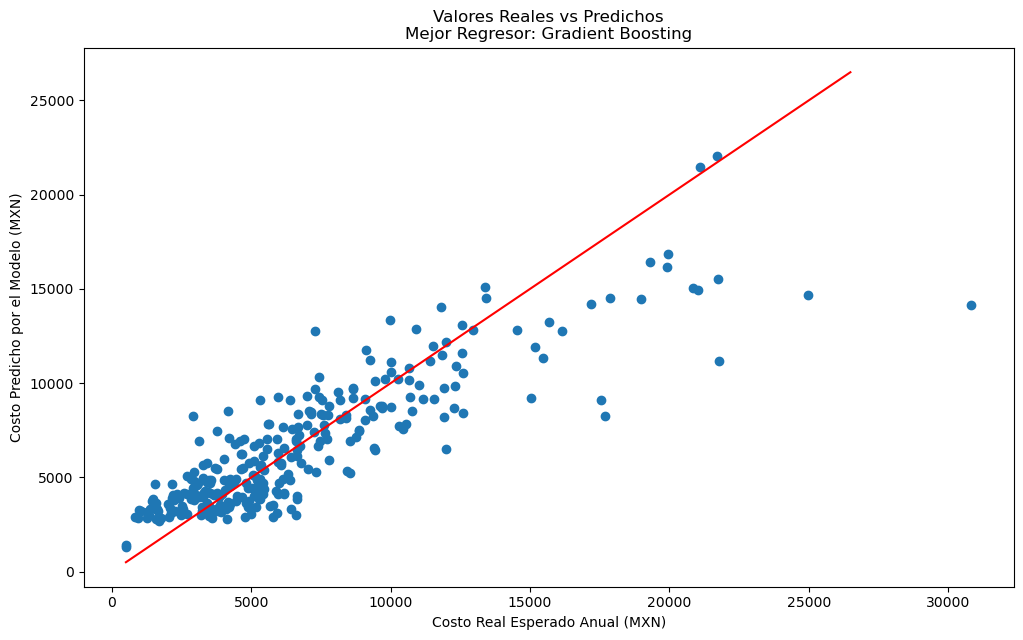

In [366]:
mejor_modelo_nombre = comparacion_regresion_val.index[0]
mejor_pipeline = regresion_pipelines[mejor_modelo_nombre]

y_pred_val = mejor_pipeline.predict(X_val)

plt.figure(figsize=(12, 7))
plt.scatter(x=y_reg_val, y=y_pred_val)

limite_max = max(y_reg_test.max(), y_pred_val.max())
limite_min = min(y_reg_test.min(), y_pred_val.min())
plt.plot([limite_min, limite_max], [limite_min, limite_max], color="red")

plt.title(f"Valores Reales vs Predichos\nMejor Regresor: {mejor_modelo_nombre}")
plt.xlabel("Costo Real Esperado Anual (MXN)")
plt.ylabel("Costo Predicho por el Modelo (MXN)")
plt.show()

### 4.2 Entrenamiento de modelos de clasificación 

Los árboles no son sensibles a la escala. Omitimos el preprocesamiento.

In [367]:
modelos_clasificacion = {
    "Dummy prior": (DummyClassifier(strategy = "prior"), False),
    "Logística balanceada": (LogisticRegression(class_weight='balanced', max_iter=3000, random_state=RANDOM_STATE), True),
    "Árbol balanceado": (DecisionTreeClassifier(max_depth=5, min_samples_leaf=10, class_weight='balanced', random_state=RANDOM_STATE), False),
    "Random Forest balanceado": (RandomForestClassifier(n_estimators=300, min_samples_leaf=3, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1), False),
    "Gradient Boosting": (GradientBoostingClassifier(random_state = RANDOM_STATE), False)
}

clas_pipelines_validacion = {}
filas = []

for nombre, (modelo, escalar) in modelos_clasificacion.items():
    pipe = crear_pipeline(modelo, escalar_numericas = escalar) 
    pipe.fit(X_train, y_clas_train)
    prob_val = extraer_proba(pipe, X_val)
    metricas = metricas_clasificacion(y_clas_val, prob_val, umbral=0.50)
    filas.append({'modelo': nombre, **metricas})
    clas_pipelines_validacion[nombre] = pipe

comparacion_clasificacion_val = pd.DataFrame(filas).set_index('modelo').sort_values('PR_AUC', ascending=False)
display(comparacion_clasificacion_val.round(4))

,accuracy,precision,recall,F1,ROC_AUC,PR_AUC,TN,FP,FN,TP
modelo,,,,,,,,,,
Logística balanceada,0.9122,0.6531,0.7805,0.7111,0.9543,0.8160,238,17,9,32
Random Forest balanceado,0.9122,0.6744,0.7073,0.6905,0.9354,0.8100,241,14,12,29
Gradient Boosting,0.9291,0.8333,0.6098,0.7042,0.9629,0.8055,250,5,16,25
Árbol balanceado,0.8818,0.5536,0.7561,0.6392,0.9033,0.7075,230,25,10,31
Dummy prior,0.8615,0.0000,0.0000,0.0000,0.5000,0.1385,255,0,41,0


### 4.3 Búsqueda del umbral de validación óptimo

Clasificador seleccionado con validación: Logística balanceada
Criterio: Se maximizó F1 sujeto a recall >= 0.85.
Umbral elegido: 0.4

Umbrales ordenados por mejor F1-Score:


,umbral,accuracy,precision,recall,F1,ROC_AUC,PR_AUC,TN,FP,FN,TP
33,0.76,0.9426,0.8529,0.7073,0.7733,0.9543,0.816,250,5,12,29
32,0.74,0.9426,0.8529,0.7073,0.7733,0.9543,0.816,250,5,12,29
31,0.72,0.9426,0.8529,0.7073,0.7733,0.9543,0.816,250,5,12,29
34,0.78,0.9426,0.8529,0.7073,0.7733,0.9543,0.816,250,5,12,29
29,0.68,0.9358,0.7895,0.7317,0.7595,0.9543,0.816,247,8,11,30


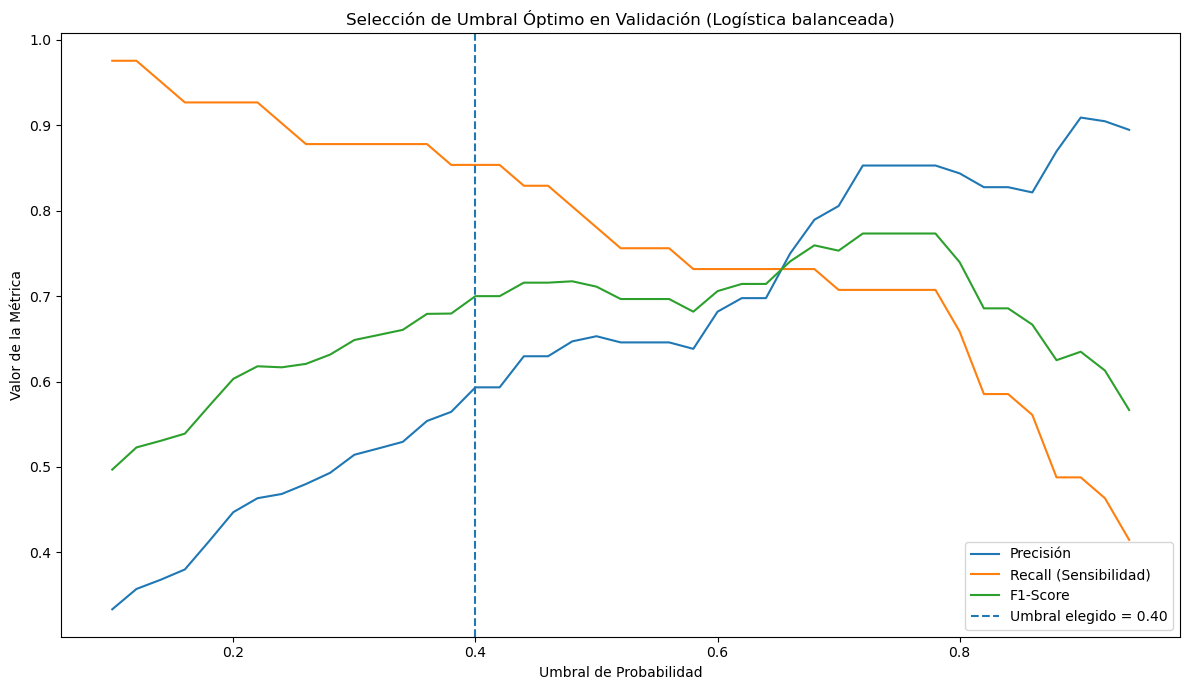

In [368]:
mejor_modelo_clas_nombre = comparacion_clasificacion_val.index[0]
mejor_pipeline_clas = clas_pipelines_validacion[mejor_modelo_clas_nombre]

prob_val = extraer_proba(mejor_pipeline_clas, X_val)

RECALL_MINIMO = 0.85
umbrales = np.round(np.arange(0.10, 0.95, 0.02), 2)
filas_umbral = []

for umbral in umbrales:
    filas_umbral.append({'umbral': umbral, **metricas_clasificacion(y_clas_val, prob_val, umbral)})

tabla_umbrales = pd.DataFrame(filas_umbral)

candidatos_umbral = tabla_umbrales.loc[tabla_umbrales['recall'] >= RECALL_MINIMO]

if candidatos_umbral.empty:
    fila_umbral = tabla_umbrales.sort_values(['F1', 'recall'], ascending=False).iloc[0]
    criterio_umbral = "No se alcanzó el recall mínimo. Se eligió por F1."
else:
    fila_umbral = candidatos_umbral.sort_values(['F1', 'precision'], ascending=False).iloc[0]
    criterio_umbral = f"Se maximizó F1 sujeto a recall >= {RECALL_MINIMO:.2f}."

umbral_elegido = float(fila_umbral['umbral'])

print('Clasificador seleccionado con validación:', mejor_modelo_clas_nombre)
print('Criterio:', criterio_umbral)
print('Umbral elegido:', umbral_elegido)
print('\nUmbrales ordenados por mejor F1-Score:')
display(tabla_umbrales.sort_values('F1', ascending=False).head().round(4))

plt.figure(figsize = (12, 7))
plt.plot(tabla_umbrales['umbral'], tabla_umbrales['precision'], label='Precisión')
plt.plot(tabla_umbrales['umbral'], tabla_umbrales['recall'], label='Recall (Sensibilidad)')
plt.plot(tabla_umbrales['umbral'], tabla_umbrales['F1'], label='F1-Score')
plt.axvline(umbral_elegido, linestyle='--', label=f'Umbral elegido = {umbral_elegido:.2f}')

plt.title(f'Selección de Umbral Óptimo en Validación ({mejor_modelo_clas_nombre})')
plt.xlabel('Umbral de Probabilidad')
plt.ylabel('Valor de la Métrica')
plt.legend(frameon=True)
plt.tight_layout()
plt.show()

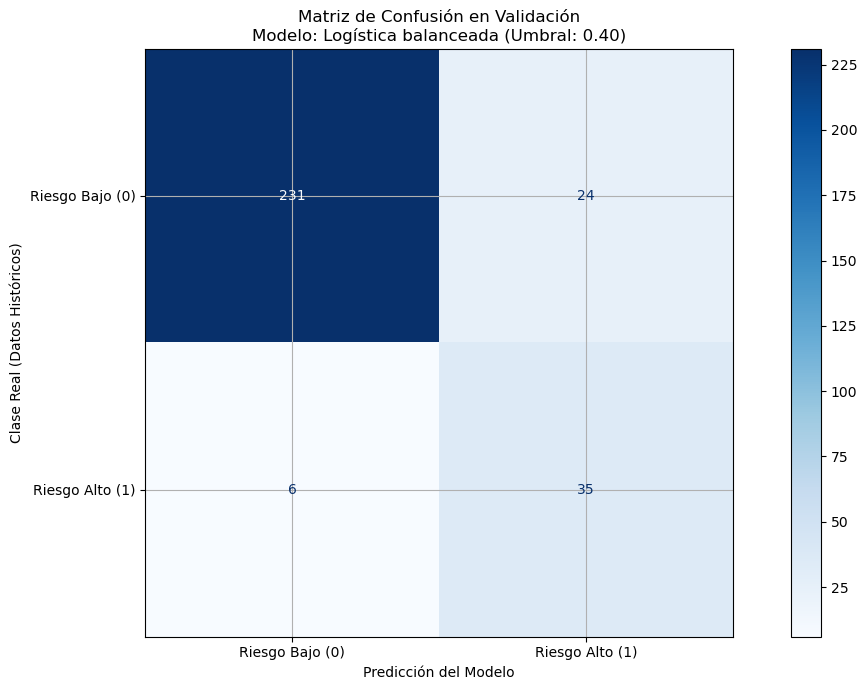

In [369]:
y_pred_val_umbral = (prob_val >= umbral_elegido).astype(int)

cm = confusion_matrix(y_clas_val, y_pred_val_umbral)

fig, ax = plt.subplots(figsize=(12, 7))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, 
    display_labels=['Riesgo Bajo (0)', 'Riesgo Alto (1)']
)

disp.plot(ax=ax, cmap='Blues', values_format='d')

plt.title(f"Matriz de Confusión en Validación\nModelo: {mejor_modelo_clas_nombre} (Umbral: {umbral_elegido:.2f})")
plt.xlabel("Predicción del Modelo")
plt.ylabel("Clase Real (Datos Históricos)")
ax.grid()

plt.tight_layout()
plt.show()

### 4.4 Reducción de dimensión

- Construir una matriz de características después del preprocesamiento.
- Aplicar PCA con 2 componentes para visualización.
- Graficar las pólizas en el plano PCA coloreando por riesgo_alto o clase_costo.
- Explicar varianza explicada y si PCA ayuda a visualizar grupos de riesgo.

In [370]:
pipeline_pca = Pipeline([
    ("feature engineering", ActuarialFeatureEngineer()),
    ("preprocesado", crea_preprocesador(escalar_numericas = True))
])

X_train_red = pipeline_pca.fit_transform(X_train)
X_val_red = pipeline_pca.transform(X_val)
X_test_red = pipeline_pca.transform(X_test)

pca = PCA(n_components = 2, random_state = RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_red)
X_val_pca = pca.transform(X_val_red)
X_test_pca = pca.transform(X_test_red)

idx_pca = list(id_train) + list(id_val) + list(id_test
                                               )
df_pca = pd.DataFrame(np.vstack([X_train_pca, X_val_pca, X_test_pca]),
                      columns = ["PC1", "PC2"],
                      index = idx_pca)

print("Varianza explicada por cada componente:", pca.explained_variance_ratio_)
print("Varianza total explicada", pca.explained_variance_ratio_.sum())

df_pca["riesgo_alto"] = df.loc[df_pca.index, "riesgo_alto"].values
df_pca["clase_costo"] = df.loc[df_pca.index, "clase_costo"].values

Varianza explicada por cada componente: [0.11119437 0.0655191 ]
Varianza total explicada 0.1767134690536225


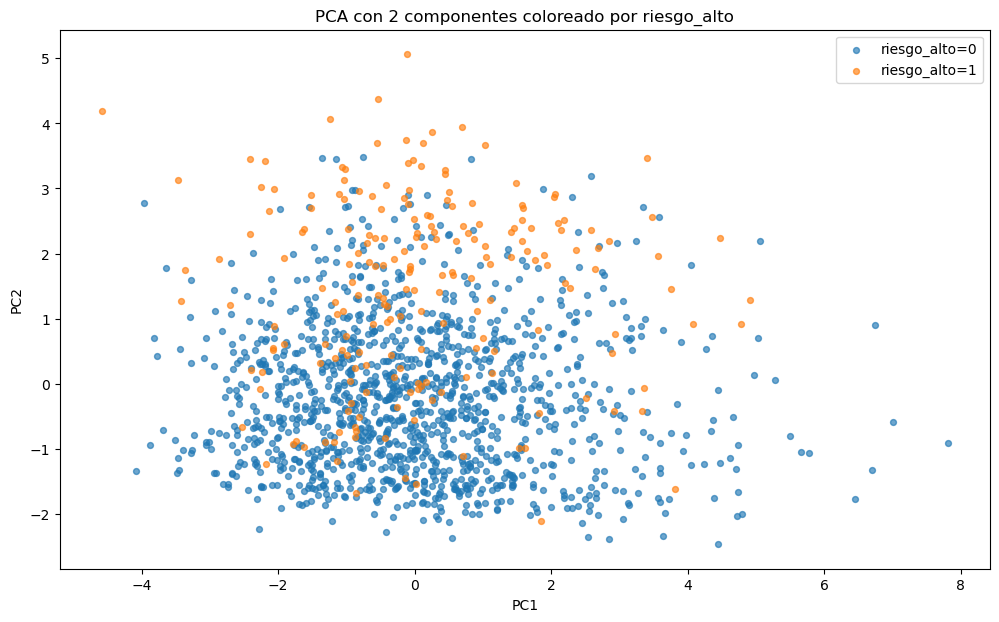

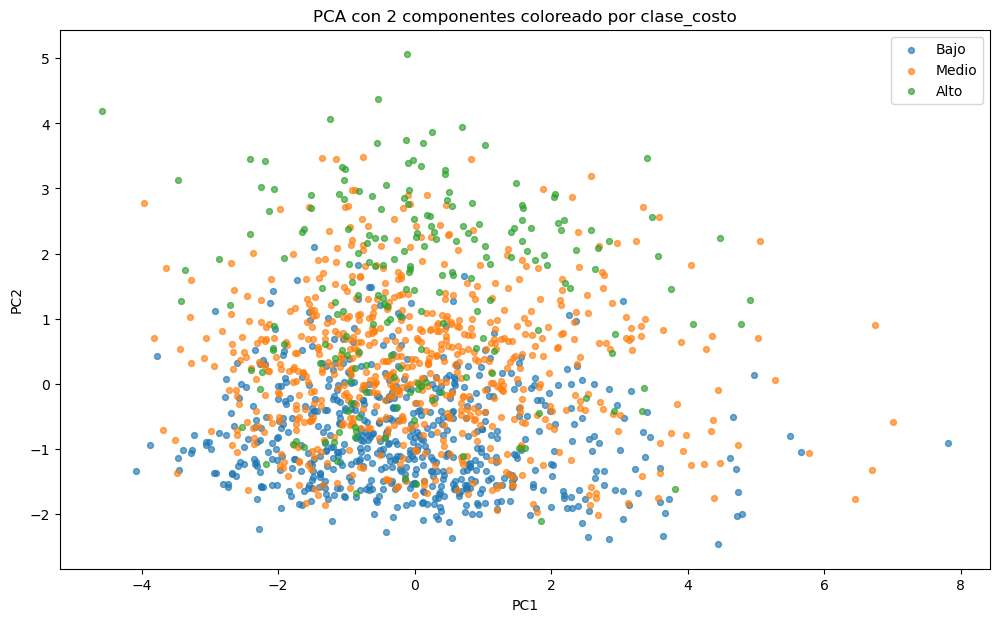

In [371]:
plt.figure(figsize=(12, 7))
for clase in sorted(df_pca['riesgo_alto'].unique()):
    subset = df_pca[df_pca['riesgo_alto'] == clase]
    plt.scatter(subset['PC1'], subset['PC2'], s=18, alpha=0.65, label=f'riesgo_alto={clase}')
plt.title('PCA con 2 componentes coloreado por riesgo_alto')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.show()

plt.figure(figsize=(12, 7))
for clase in ['Bajo', 'Medio', 'Alto']:
    subset = df_pca[df_pca['clase_costo'] == clase]
    plt.scatter(subset['PC1'], subset['PC2'], s=18, alpha=0.65, label=clase)
plt.title('PCA con 2 componentes coloreado por clase_costo')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.show()

La varianza sirve para entender qué tanto explican los componentes al conjunto original.

En este caso, PCA no ayuda a visualizar grupos. El PCA da como resultado una muestra homogénea y no conjuntos separados.

### 4.5 Evaluación final. Uso del set test

Graficaremos la mejor regresión y el mejor clasificador usando el umbral optimizado con el set de validación.

,MAE,RMSE,R2
Gradient Boosting,1574.505584,2460.854355,0.713386


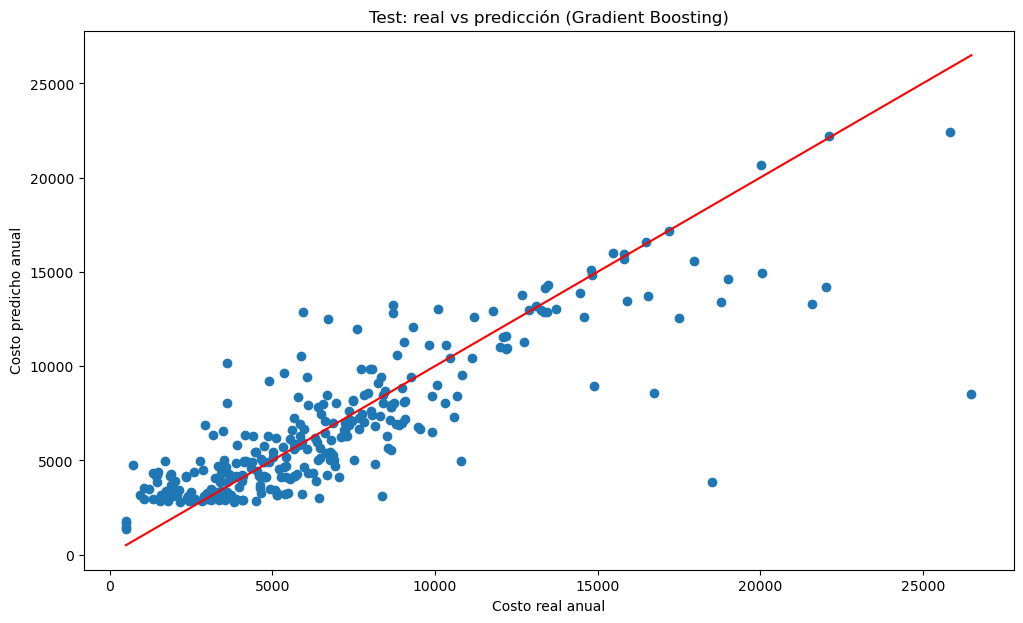

In [372]:
pred_reg_test = mejor_pipeline.predict(X_test)
metricas_reg_test = metricas_regresion(y_reg_test, pred_reg_test)
display(pd.DataFrame([metricas_reg_test], index = [mejor_modelo_nombre]))

plt.figure(figsize = (12, 7))
plt.scatter(y_reg_test, pred_reg_test)
lim_min = min(y_reg_test.min(), pred_reg_test.min())
lim_max = max(y_reg_test.max(), pred_reg_test.max())
plt.plot([lim_min, lim_max], [lim_min, lim_max], label = "Predicción", color = "red")
plt.title(f"Test: real vs predicción ({mejor_modelo_nombre})")
plt.xlabel("Costo real anual")
plt.ylabel("Costo predicho anual")

plt.show()

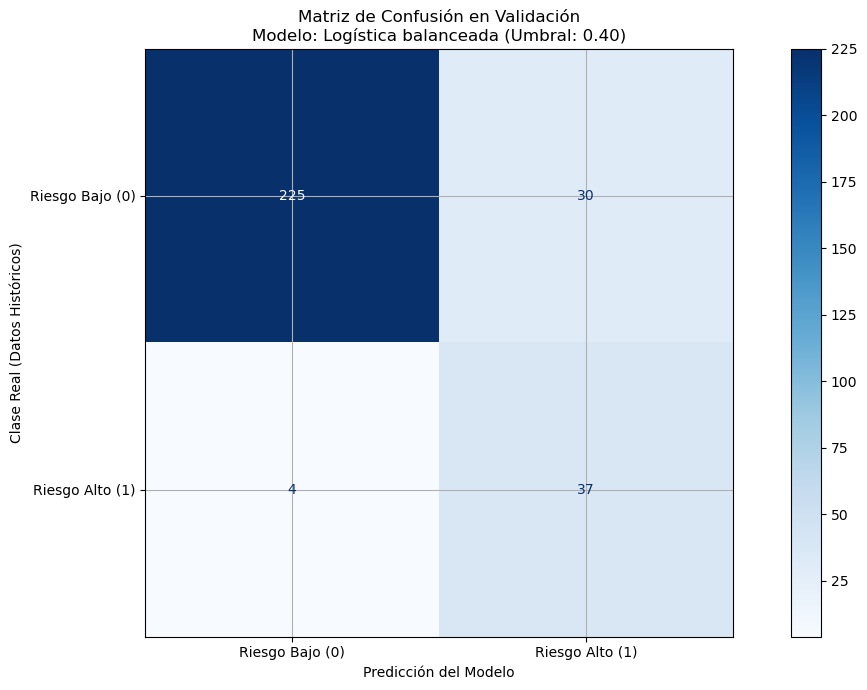

In [373]:
prob_test = extraer_proba(mejor_pipeline_clas, X_test)

y_pred_test_umbral = (prob_test >= umbral_elegido).astype(int)

cm = confusion_matrix(y_clas_test, y_pred_test_umbral)

fig, ax = plt.subplots(figsize=(12, 7))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, 
    display_labels=['Riesgo Bajo (0)', 'Riesgo Alto (1)']
)

disp.plot(ax=ax, cmap='Blues', values_format='d')

plt.title(f"Matriz de Confusión en Validación\nModelo: {mejor_modelo_clas_nombre} (Umbral: {umbral_elegido:.2f})")
plt.xlabel("Predicción del Modelo")
plt.ylabel("Clase Real (Datos Históricos)")
ax.grid()

plt.tight_layout()
plt.show()

Métricas finales

In [374]:
metricas_clas_test = metricas_clasificacion(
    y_clas_test,
    prob_test,
    umbral=umbral_elegido
)

display(
    pd.DataFrame([metricas_clas_test], index=[mejor_modelo_clas_nombre]).round(4)
)

,accuracy,precision,recall,F1,ROC_AUC,PR_AUC,TN,FP,FN,TP
Logística balanceada,0.8851,0.5522,0.9024,0.6852,0.9417,0.7676,225,30,4,37


### 5. Interpretación

Explicar coeficientes de modelos lineales, variables importantes del Random Forest y posibles sesgos del modelo.

<Axes: title={'center': 'Importancia de las variables (Gradient Boosting)'}, ylabel='feature'>

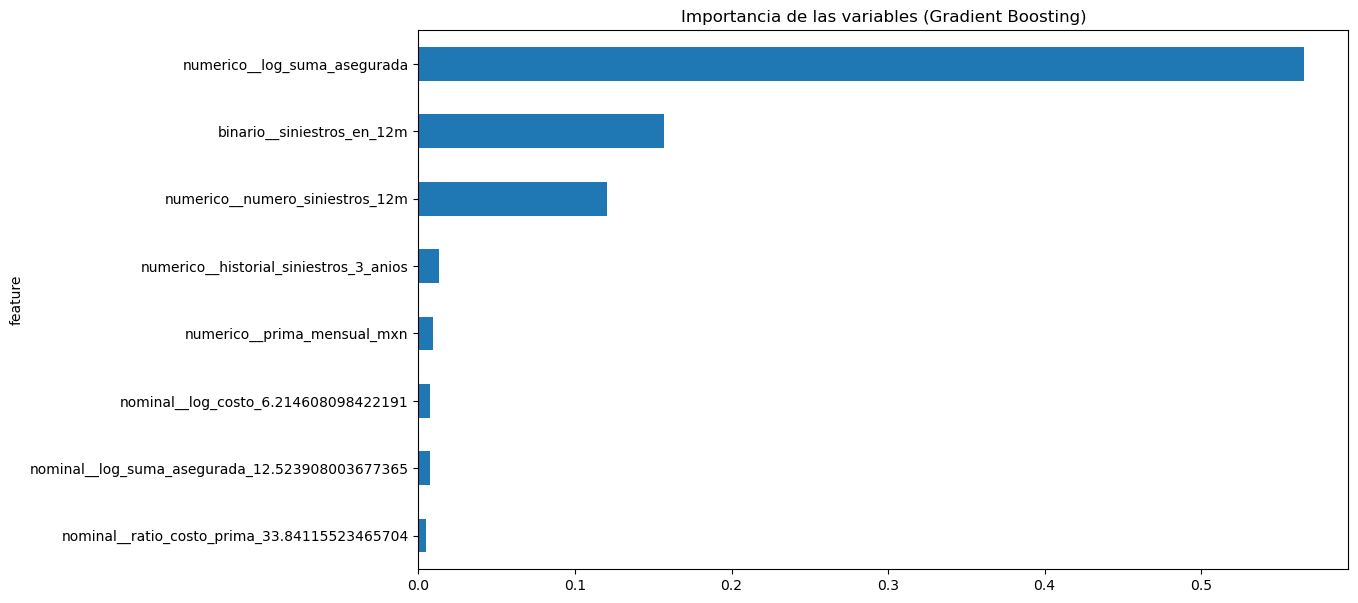

In [375]:
xgb_reg = regresion_pipelines.get("Gradient Boosting")
features_xgb = nombres_features(xgb_reg)
coefi = xgb_reg.named_steps["model"].feature_importances_
coef_df = pd.DataFrame({
    "feature": features_xgb,
    "coeficiente": coefi
})

coef_df.set_index("feature")["coeficiente"].sort_values().tail(8).plot(
    kind = "barh", 
    figsize = (12, 7), 
    title = "Importancia de las variables (Gradient Boosting)"
)


Parámetros importantes de Random Forest para regresión

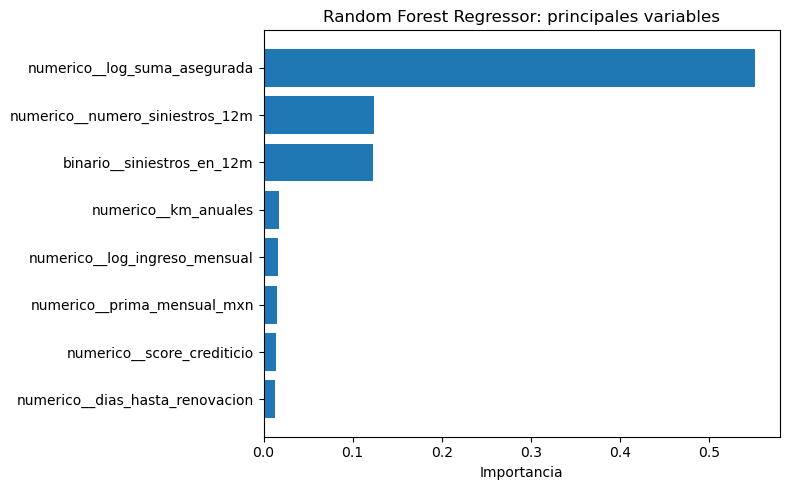

In [376]:
rf_reg_pipe = regresion_pipelines.get('Random Forest')
nombres_features_rf_reg = nombres_features(rf_reg_pipe)
importancias_rf_reg = rf_reg_pipe.named_steps['model'].feature_importances_
importancias_reg_df = pd.DataFrame({'feature': nombres_features_rf_reg, 'importance': importancias_rf_reg}).sort_values('importance', ascending=False)
importancias_reg_df.to_csv(OUTPUTS_DIR / 'importancias_rf_regresion.csv', index=False)
plt.figure(figsize=(8, 5))
top_imp = importancias_reg_df.head(8).sort_values('importance')
plt.barh(top_imp['feature'], top_imp['importance'])
plt.title('Random Forest Regressor: principales variables')
plt.xlabel('Importancia')
plt.tight_layout()
plt.show()

Parámetros importantes de Random Forest para clasificación

,feature,importance
12,numerico__log_suma_asegurada,0.085653
2659,binario__siniestros_en_12m,0.085005
2655,ordinal__segmento_marca,0.078030
3,numerico__prima_mensual_mxn,0.058667
10,numerico__numero_siniestros_12m,0.055956
2660,binario__prima_mayor_a_mediana,0.045486
11,numerico__log_ingreso_mensual,0.037323
14,numerico__log_km_totales,0.036222
6,numerico__km_anuales,0.029761
13,numerico__km_totales,0.028591


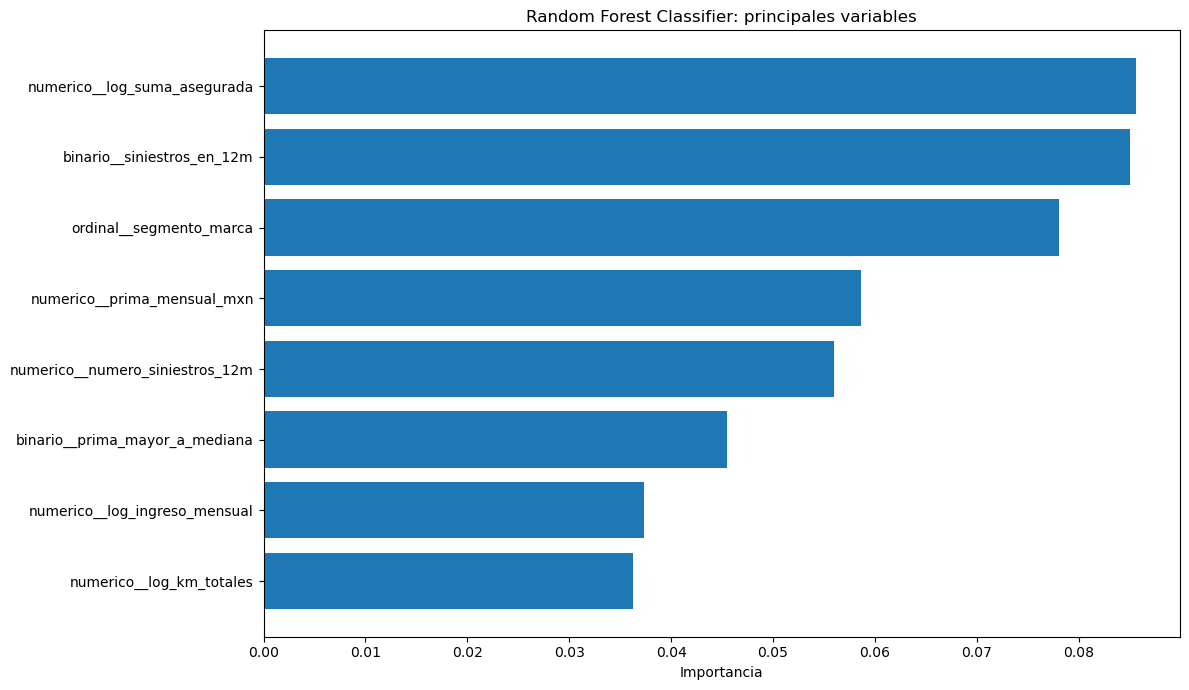

In [377]:
rf_clas_pipe = clas_pipelines_validacion.get('Random Forest balanceado')
nombres_features_rf_clas = nombres_features(rf_clas_pipe)
coef_rf_clas = rf_clas_pipe.named_steps['model'].feature_importances_
coef_clas_df = pd.DataFrame({'feature': nombres_features_rf_clas, 'importance': coef_rf_clas}).sort_values('importance', ascending=False)
display(coef_clas_df.head(15))
coef_clas_df.to_csv(OUTPUTS_DIR / 'importancias_rf_clasificacion.csv', index=False)
plt.figure(figsize=(12, 7))
top_imp_clf = coef_clas_df.head(8).sort_values('importance')
plt.barh(top_imp_clf['feature'], top_imp_clf['importance'])
plt.title('Random Forest Classifier: principales variables')
plt.xlabel('Importancia')
plt.tight_layout()
plt.show()

## Exportación de resultados con joblib

In [378]:
import unicodedata


def limpiar_nombre(nombre):
    nombre = unicodedata.normalize("NFKD", nombre).encode("ascii", "ignore").decode("utf-8")
    nombre = nombre.lower().replace(" ", "_")
    return "".join(caracter for caracter in nombre if caracter.isalnum() or caracter == "_")


modelos_exportados = []

for nombre, pipeline in regresion_pipelines.items():
    nombre_archivo = f"regresion_{limpiar_nombre(nombre)}.joblib"
    ruta_modelo = MODELS_DIR / nombre_archivo
    joblib.dump(pipeline, ruta_modelo)

    modelos_exportados.append({
        "tipo": "regresion",
        "modelo": nombre,
        "archivo": nombre_archivo
    })


for nombre, pipeline in clas_pipelines_validacion.items():
    nombre_archivo = f"clasificacion_{limpiar_nombre(nombre)}.joblib"
    ruta_modelo = MODELS_DIR / nombre_archivo
    joblib.dump(pipeline, ruta_modelo)

    modelos_exportados.append({
        "tipo": "clasificacion",
        "modelo": nombre,
        "archivo": nombre_archivo
    })


joblib.dump(mejor_pipeline, MODELS_DIR / "mejor_modelo_regresion.joblib")
joblib.dump(mejor_pipeline_clas, MODELS_DIR / "mejor_modelo_clasificacion.joblib")

metadata_modelos = {
    "mejor_modelo_regresion": mejor_modelo_nombre,
    "mejor_modelo_clasificacion": mejor_modelo_clas_nombre,
    "umbral_clasificacion": float(umbral_elegido),
    "modelos_exportados": modelos_exportados
}

with open(MODELS_DIR / "metadata_modelos.json", "w", encoding="utf-8") as archivo:
    json.dump(metadata_modelos, archivo, indent=4, ensure_ascii=False)

comparacion_regresion_val.to_csv(OUTPUTS_DIR / "comparacion_modelos_regresion.csv")
comparacion_clasificacion_val.to_csv(OUTPUTS_DIR / "comparacion_modelos_clasificacion.csv")

print("Modelos exportados en:", MODELS_DIR)
display(pd.DataFrame(modelos_exportados))

Modelos exportados en: c:\Users\PC\OneDrive\Documentos\GitHub\proyecto_seguro_actuarial\models


,tipo,modelo,archivo
0,regresion,Dummy mediana,regresion_dummy_mediana.joblib
1,regresion,Regresión lineal,regresion_regresion_lineal.joblib
2,regresion,Ridge,regresion_ridge.joblib
3,regresion,Lasso,regresion_lasso.joblib
4,regresion,Árbol,regresion_arbol.joblib
5,regresion,Random Forest,regresion_random_forest.joblib
6,regresion,Gradient Boosting,regresion_gradient_boosting.joblib
7,clasificacion,Dummy prior,clasificacion_dummy_prior.joblib
8,clasificacion,Logística balanceada,clasificacion_logistica_balanceada.joblib
9,clasificacion,Árbol balanceado,clasificacion_arbol_balanceado.joblib
